In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import uproot
import awkward as ak
import tabulate as tab
import glob
import h5py
from tqdm import tqdm

from scipy.signal import find_peaks


# Find peaks

In [2]:
## algo
def estimate_baseline_drift(record, chunk=2000, q=10):
    """
    Baseline proxy per chunk: q-th percentile (q=10 works well when pulses are positive-going).
    Returns:
      baseline_chunks: array of per-chunk baseline estimates
      drift_ptp: peak-to-peak baseline variation across record
      drift_std: std of baseline across chunks
    """
    n = len(record)
    baselines = []
    for start in range(0, n, chunk):
        seg = record[start:start + chunk]
        baselines.append(np.percentile(seg, q))
    baselines = np.asarray(baselines, dtype=np.float64)
    return baselines, float(np.ptp(baselines)), float(np.std(baselines))

def constant_fraction_crossing_index(y, peak_idx, frac=0.2, search_back=400):
    """
    Find rising-edge crossing time at `frac` of peak height, for one detected peak.

    Args:
      y: baseline-subtracted waveform (1D)
      peak_idx: index of peak maximum (from find_peaks)
      frac: fraction of peak height (e.g. 0.1, 0.2, 0.3)
      search_back: how far left of peak to search for the rising edge

    Returns:
      align_idx: integer index of threshold crossing on rising edge
                (nearest sample at or just after crossing).
                Returns None if not found.
    """
    peak_val = y[peak_idx]
    if peak_val <= 0:
        return None

    thr = frac * peak_val
    start = max(0, peak_idx - search_back)

    seg = y[start:peak_idx + 1]  # include peak sample
    # Find first index where seg goes from below thr to >= thr
    above = seg >= thr
    if not np.any(above):
        return None

    k = np.argmax(above)  # first True
    align_idx = start + k
    return int(align_idx)

def extract_peaks_from_records(
    X,
    *,
    # Peak detection (baseline-subtracted, in ADC counts)
    height=80.0,
    prominence=150.0,
    distance=150,

    # Baseline estimation for peak finding
    baseline_chunk=2000,
    baseline_q=10,

    # Drift flagging threshold (ADC counts)
    drift_ptp_threshold=200.0,

    # Constant-fraction alignment parameters
    align_frac=0.2,          # 20% is a common sweet spot
    align_search_back=400,   # how far before argmax to look
):
    """
    Args:
      X: array (N_records, N_samples)
    Returns:
      results: list of dicts, one per record with:
        - peaks_idx: (N_peaks,) indices in original trigger record
        - peaks_height: (N_peaks,) baseline-subtracted peak heights
        - baseline_trace: (N_samples,) piecewise-linear baseline estimate (qth percentile per chunk)
        - baseline_chunks: (N_chunks,) raw chunk baselines
        - drift_ptp, drift_std
        - flagged_drift: bool

        - align_idx: constant-fraction rising-edge crossing indices
    """
    results = []
    n_records, n_samples = X.shape

    for r in range(n_records):
        rec = X[r].astype(np.float64, copy=False)

        # Chunk baseline estimates (robust to pulses if q is low)
        baseline_chunks, drift_ptp, drift_std = estimate_baseline_drift(
            rec, chunk=baseline_chunk, q=baseline_q
        )

        # Build a baseline trace by interpolating chunk baselines to all samples
        centers = np.arange(len(baseline_chunks)) * baseline_chunk + (baseline_chunk - 1) / 2
        centers = np.clip(centers, 0, n_samples - 1)
        idx = np.arange(n_samples)
        baseline_trace = np.interp(idx, centers, baseline_chunks)

        # Baseline-subtracted waveform for peak finding
        y = rec - baseline_trace

        # Peak detection
        peaks_idx, props = find_peaks(
            y,
            height=height,
            prominence=prominence,
            distance=distance,
        )

        peaks_height = props["peak_heights"]  # same length as peaks_idx

        # Compute constant-fraction alignment indices
        align_idx = np.full_like(peaks_idx, fill_value=-1, dtype=np.int32)
        for i, p in enumerate(peaks_idx):
            a = constant_fraction_crossing_index(
                y, int(p),
                frac=align_frac,
                search_back=align_search_back
            )
            align_idx[i] = -1 if a is None else a

        # You may want to drop peaks where alignment failed
        ok = align_idx >= 0

        results.append({
            "record_index": r,

            "peaks_idx": peaks_idx.astype(np.int32), # peak position in the trigger record
            "peaks_height": peaks_height.astype(np.float32),
            "peaks_prominence": props["prominences"].astype(np.float32),

            # constant-fraction crossing
            "align_idx": align_idx.astype(np.int32),  # alignment      
            "align_frac": float(align_frac),

            "baseline_chunks": baseline_chunks.astype(np.float32),
            "baseline_trace": baseline_trace.astype(np.float32),
            "drift_ptp": drift_ptp,
            "drift_std": drift_std,
            "flagged_drift": bool(drift_ptp > drift_ptp_threshold),

            # convenience counts
            "n_peaks": int(len(peaks_idx)),
            "n_aligned": int(np.sum(ok))
        })

    return results

In [3]:
## plots

def plot_record_qc_from_result(
    X,
    result: dict,
    *,
    pre: int = 40,
    post: int = 216,
    max_pulses_to_plot: int | None = 200,
    show_baseline_overlay: bool = True,
):
    """
    QC plot driven by a single 'result' dict (one record entry from `results`).
    Uses:
      - result["record_index"]
      - result["baseline_trace"]
      - result["peaks_idx"]
      - drift stats + flagged status

    Returns:
      windows: (N_valid_peaks, pre+post) baseline-subtracted windows
      valid_peaks: indices in original record of peaks actually windowed (not near edges)
    """
    i = int(result["record_index"])
    rec = X[i].astype(np.float64, copy=False)

    baseline = np.asarray(result["baseline_trace"], dtype=np.float64)
    # peaks = np.asarray(result["peaks_idx"], dtype=np.int64)
    peaks = np.asarray(result["align_idx"], dtype=np.int64)

    # Baseline-subtracted waveform
    y = rec - baseline

    # Extract windows around peaks
    win_len = pre + post
    windows = []
    valid_peaks = []
    for p in peaks:
        start = p - pre
        end = p + post
        if start < 0 or end > len(y):
            continue
        windows.append(y[start:end])
        valid_peaks.append(p)

    windows = np.asarray(windows, dtype=np.float64)
    valid_peaks = np.asarray(valid_peaks, dtype=np.int32)

    # Cap pulses plotted for readability
    windows_plot = windows
    if max_pulses_to_plot is not None and len(windows) > max_pulses_to_plot:
        idx = np.random.choice(len(windows), size=max_pulses_to_plot, replace=False)
        windows_plot = windows[idx]

    # ---- Plot layout ----
    fig = plt.figure(figsize=(16, 6), constrained_layout=True)
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    ax_raw = fig.add_subplot(gs[0, 0])
    ax_sub = fig.add_subplot(gs[1, 0], sharex=ax_raw)
    ax_win = fig.add_subplot(gs[:, 1])

    # A) Raw waveform (+ baseline overlay)
    ax_raw.plot(rec, linewidth=1)
    if show_baseline_overlay:
        ax_raw.plot(baseline, linewidth=1.5)
    ax_raw.set_title(
        f"Record {i}: raw waveform" + (" (baseline overlay)" if show_baseline_overlay else "")
    )
    ax_raw.set_ylabel("ADC")
    ax_raw.grid(True, alpha=0.25)

    # Info box (pulled from dict)
    drift_ptp = float(result.get("drift_ptp", np.nan))
    drift_std = float(result.get("drift_std", np.nan))
    flagged = bool(result.get("flagged_drift", False))

    info = (
        f"peaks detected: {len(peaks)}\n"
        f"peaks windowed: {len(valid_peaks)}\n"
        f"drift_ptp: {drift_ptp:.1f}\n"
        f"drift_std: {drift_std:.1f}\n"
        f"flagged: {flagged}"
    )
    ax_raw.text(
        0.01, 0.98, info,
        transform=ax_raw.transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round", alpha=0.85),
        fontsize=10
    )

    # B) Baseline-subtracted + peaks
    ax_sub.plot(y, linewidth=1)
    if len(valid_peaks) > 0:
        ax_sub.scatter(valid_peaks, y[valid_peaks], marker="x", s=40)
    ax_sub.set_title("Baseline-subtracted waveform with detected peaks (✕)")
    ax_sub.set_xlabel("Sample index")
    ax_sub.set_ylabel("ADC (subtracted)")
    ax_sub.grid(True, alpha=0.25)

    # C) Superimposed windows (aligned)
    if len(windows_plot) > 0:
        t = np.arange(win_len) - pre
        ax_win.plot(t, windows_plot.T, linewidth=0.8, alpha=0.35)
        ax_win.axvline(0, linestyle="--", linewidth=1)
    ax_win.set_title(f"Extracted pulse windows superimposed (n={len(windows_plot)})")
    ax_win.set_xlabel("Samples relative to peak (0 = peak)")
    ax_win.set_ylabel("ADC (subtracted)")
    ax_win.grid(True, alpha=0.25)

    plt.show()
    return windows, valid_peaks



def plot_pulses_across_triggers(
    X,
    results,
    *,
    pre: int = 40,
    post: int = 216,

    # --- position cut ---
    use_pos: str = "align",           # "align" or "argmax"
    pos_side: str = "before",         # "before", "after", "between", "none"
    pos_cut=20000,                    # int or (lo,hi)

    # --- ADC / amplitude cut (baseline-subtracted) ---
    amp_side: str = "none",           # "below", "above", "between", "none"
    amp_cut=500.0,                    # float or (lo,hi) in ADC counts (baseline-subtracted)
    amp_source: str = "peak",         # "peak" uses peaks_height (recommended)

    # plotting options
    max_pulses_to_plot: int | None = 2000,
    mean_mode: str = "overlay",       # "overlay", "separate", "none"
    show_mean_band: bool = True,
    require_full_window: bool = True,
    skip_flagged: bool = False,
):
    """
    Collect pulses from all records based on:
      - a cut on peak position (align_idx or peaks_idx)
      - a cut on amplitude (ADC)

    Returns:
      windows: (N_selected, pre+post) baseline-subtracted windows
      meta: dict with record_index, peak_position, peak_height
    """
    assert use_pos in ("align", "argmax")
    assert pos_side in ("before", "after", "between", "none")
    assert amp_side in ("below", "above", "between", "none")
    assert mean_mode in ("overlay", "separate", "none")
    assert amp_source in ("peak",)

    win_len = pre + post
    all_windows = []
    all_rec_idx = []
    all_pos = []
    all_amp = []

    for r, res in enumerate(results):
        if skip_flagged and bool(res.get("flagged_drift", False)):
            continue

        rec = X[r].astype(np.float64, copy=False)
        baseline = np.asarray(res["baseline_trace"], dtype=np.float64)
        y = rec - baseline

        # Arrays per detected pulse
        pos_arr = np.asarray(res["align_idx"] if use_pos == "align" else res["peaks_idx"], dtype=np.int64)
        amp_arr = np.asarray(res["peaks_height"], dtype=np.float64)  # baseline-subtracted peak height at argmax

        # ---- build selection mask ----
        mask = np.ones(len(pos_arr), dtype=bool)

        # Position cut
        if pos_side != "none":
            if pos_side == "before":
                mask &= (pos_arr < int(pos_cut))
            elif pos_side == "after":
                mask &= (pos_arr > int(pos_cut))
            else:  # between
                lo, hi = pos_cut
                mask &= (pos_arr >= int(lo)) & (pos_arr <= int(hi))

        # Amplitude cut
        if amp_side != "none":
            if amp_side == "below":
                mask &= (amp_arr < float(amp_cut))
            elif amp_side == "above":
                mask &= (amp_arr > float(amp_cut))
            else:  # between
                lo, hi = amp_cut
                mask &= (amp_arr >= float(lo)) & (amp_arr <= float(hi))

        # Apply selection
        sel_pos = pos_arr[mask]
        sel_amp = amp_arr[mask]

        for p, a in zip(sel_pos, sel_amp):
            start = p - pre
            end = p + post
            if require_full_window and (start < 0 or end > len(y)):
                continue
            if start < 0 or end > len(y):
                continue
            all_windows.append(y[start:end])
            all_rec_idx.append(r)
            all_pos.append(int(p))
            all_amp.append(float(a))

    windows = np.asarray(all_windows, dtype=np.float64)
    meta = {
        "record_index": np.asarray(all_rec_idx, dtype=np.int32),
        "peak_position": np.asarray(all_pos, dtype=np.int32),
        "peak_height": np.asarray(all_amp, dtype=np.float32),
    }

    if windows.size == 0:
        print("No pulses matched the selection (try changing pos/amp cuts).")
        return windows, meta

    # Optional downsample only for drawing
    windows_plot = windows
    if max_pulses_to_plot is not None and len(windows) > max_pulses_to_plot:
        idx = np.random.choice(len(windows), size=max_pulses_to_plot, replace=False)
        windows_plot = windows[idx]

    # Mean/std computed from ALL selected windows (not the plotted subset)
    mean = windows.mean(axis=0)
    std = windows.std(axis=0)

    # ---- Plot ----
    if mean_mode == "separate":
        fig, (ax_all, ax_mean) = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    else:
        fig, ax_all = plt.subplots(1, 1, figsize=(9, 5), constrained_layout=True)
        ax_mean = None

    t = np.arange(win_len) - pre

    ax_all.plot(t, windows_plot.T, linewidth=0.6, alpha=0.15)
    ax_all.axvline(0, linestyle="--", linewidth=1)
    ax_all.set_xlabel("Samples relative to alignment (0 = chosen position index)")
    ax_all.set_ylabel("ADC (baseline-subtracted)")
    ax_all.grid(True, alpha=0.25)

    # Titles: build readable selection text
    def _pos_txt(side, cut, label):
        side = str(side).strip().lower()
        if side == "none":
            return f"{label}: none"
        if side == "before":
            return f"{label} < {cut}"
        if side == "after":
            return f"{label} > {cut}"
        if side == "between":
            if not (isinstance(cut, (tuple, list)) and len(cut) == 2):
                raise TypeError(f"{label}: for side='between', cut must be (lo, hi); got {cut!r}")
            lo, hi = cut
            return f"{label} in [{lo}, {hi}]"
        raise ValueError(f"Unknown pos_side {side!r} (expected none/before/after/between)")

    def _amp_txt(side, cut, label):
        side = str(side).strip().lower()
        if side == "none":
            return f"{label}: none"
        if side == "below":
            return f"{label} < {cut}"
        if side == "above":
            return f"{label} > {cut}"
        if side == "between":
            if not (isinstance(cut, (tuple, list)) and len(cut) == 2):
                raise TypeError(f"{label}: for side='between', cut must be (lo, hi); got {cut!r}")
            lo, hi = cut
            return f"{label} in [{lo}, {hi}]"
        raise ValueError(f"Unknown amp_side {side!r} (expected none/below/above/between)")

    pos_txt = _pos_txt(pos_side, pos_cut, f"{use_pos}_idx")
    amp_txt = _amp_txt(amp_side, amp_cut, "ADC_peak")

    ax_all.set_title(f"Pulses across triggers | {pos_txt} | {amp_txt} | N={len(windows)}")

    if mean_mode == "overlay":
        ax_all.plot(t, mean, linewidth=2.0, alpha=0.9)
        if show_mean_band:
            ax_all.fill_between(t, mean - std, mean + std, alpha=0.15)

    if mean_mode == "separate" and ax_mean is not None:
        ax_mean.plot(t, mean, linewidth=2.0)
        ax_mean.axvline(0, linestyle="--", linewidth=1)
        if show_mean_band:
            ax_mean.fill_between(t, mean - std, mean + std, alpha=0.15)
        ax_mean.set_title("Mean pulse of selection" + (" (±1σ)" if show_mean_band else ""))
        ax_mean.set_xlabel("Samples relative to alignment")
        ax_mean.set_ylabel("ADC (baseline-subtracted)")
        ax_mean.grid(True, alpha=0.25)

    plt.show()
    return windows, meta


def plot_peak_position_histogram(
    results,
    *,
    use: str = "align",          # "align" or "argmax"
    bins: int | np.ndarray = 200,
    range: tuple[int, int] | None = None,
    skip_flagged: bool = False,
    density: bool = False,
    title: str | None = None,
):
    """
    Plot histogram of peak positions across all trigger records.

    Args:
      results: list of per-record dicts from extract_peaks_from_records
      use: "align" uses result["align_idx"], "argmax" uses result["peaks_idx"]
      bins: number of bins or explicit bin edges
      range: (min,max) range for histogram (optional)
      skip_flagged: if True, exclude records with flagged_drift=True
      density: if True, plot normalized PDF instead of counts
      title: override plot title

    Returns:
      positions: 1D np.ndarray of all collected peak positions
    """
    use = str(use).strip().lower()
    if use not in ("align", "argmax"):
        raise ValueError("use must be 'align' or 'argmax'")

    key = "align_idx" if use == "align" else "peaks_idx"

    positions = []
    for res in results:
        if skip_flagged and bool(res.get("flagged_drift", False)):
            continue
        arr = np.asarray(res.get(key, []), dtype=np.int64)
        # if align_idx could contain -1 (when not dropping failed), ignore them
        arr = arr[arr >= 0]
        positions.append(arr)

    if len(positions) == 0:
        positions = np.array([], dtype=np.int64)
    else:
        positions = np.concatenate(positions)

    if positions.size == 0:
        print("No peak positions found (check 'use' or skip_flagged settings).")
        return positions

    fig, ax = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)
    ax.hist(positions, bins=bins, range=range, density=density)
    ax.set_xlabel(f"Peak position in trigger (sample index) [{key}]")
    ax.set_ylabel("Density" if density else "Count")
    ax.grid(True, alpha=0.25)

    if title is None:
        title = f"Histogram of peak positions across triggers ({key}), N={len(positions)}"
        if skip_flagged:
            title += " (excluding drift-flagged records)"
    ax.set_title(title)

    plt.show()
    return positions


In [4]:
# ---- Example usage ----
if __name__ == "__main__":
    path = "trig_20_chID_0.npz"
    data = np.load(path)
    X = data["X"]  # shape (20, 65600)

    results = extract_peaks_from_records(
        X,
        height=80.0,
        prominence=150.0,
        distance=150,
        baseline_chunk=2000,
        baseline_q=10,
        drift_ptp_threshold=200.0,
    )

    # Quick summary
    for r in results:
        n_peaks = len(r["peaks_idx"])
        flag = "⚠️ DRIFT" if r["flagged_drift"] else "ok"
        print(
            f"rec {r['record_index']:02d}: peaks={n_peaks:3d}  "
            f"drift_ptp={r['drift_ptp']:.1f}  ({flag})"
        )

    # # Example: access peak positions for record 0
    # print()
    # print(results[0]["peaks_idx"])

print("\nlist of entries where the alignment failed:")
for id in range(0, len(results)):
    tot = results[id]["n_peaks"]
    ali = results[id]["n_aligned"]
    if tot != ali:
        print(id, tot, ali)

rec 00: peaks= 51  drift_ptp=25.1  (ok)
rec 01: peaks= 59  drift_ptp=288.0  (⚠️ DRIFT)
rec 02: peaks= 51  drift_ptp=109.2  (ok)
rec 03: peaks= 64  drift_ptp=18.0  (ok)
rec 04: peaks= 42  drift_ptp=17.0  (ok)
rec 05: peaks= 51  drift_ptp=237.3  (⚠️ DRIFT)
rec 06: peaks= 41  drift_ptp=34.0  (ok)
rec 07: peaks= 39  drift_ptp=13.1  (ok)
rec 08: peaks= 51  drift_ptp=100.0  (ok)
rec 09: peaks= 57  drift_ptp=285.0  (⚠️ DRIFT)
rec 10: peaks= 61  drift_ptp=446.0  (⚠️ DRIFT)
rec 11: peaks= 49  drift_ptp=42.0  (ok)
rec 12: peaks= 53  drift_ptp=188.1  (ok)
rec 13: peaks= 51  drift_ptp=121.2  (ok)
rec 14: peaks= 51  drift_ptp=109.0  (ok)
rec 15: peaks= 62  drift_ptp=47.0  (ok)
rec 16: peaks= 56  drift_ptp=159.0  (ok)
rec 17: peaks= 52  drift_ptp=19.0  (ok)
rec 18: peaks= 51  drift_ptp=46.1  (ok)
rec 19: peaks= 53  drift_ptp=80.0  (ok)

list of entries where the alignment failed:


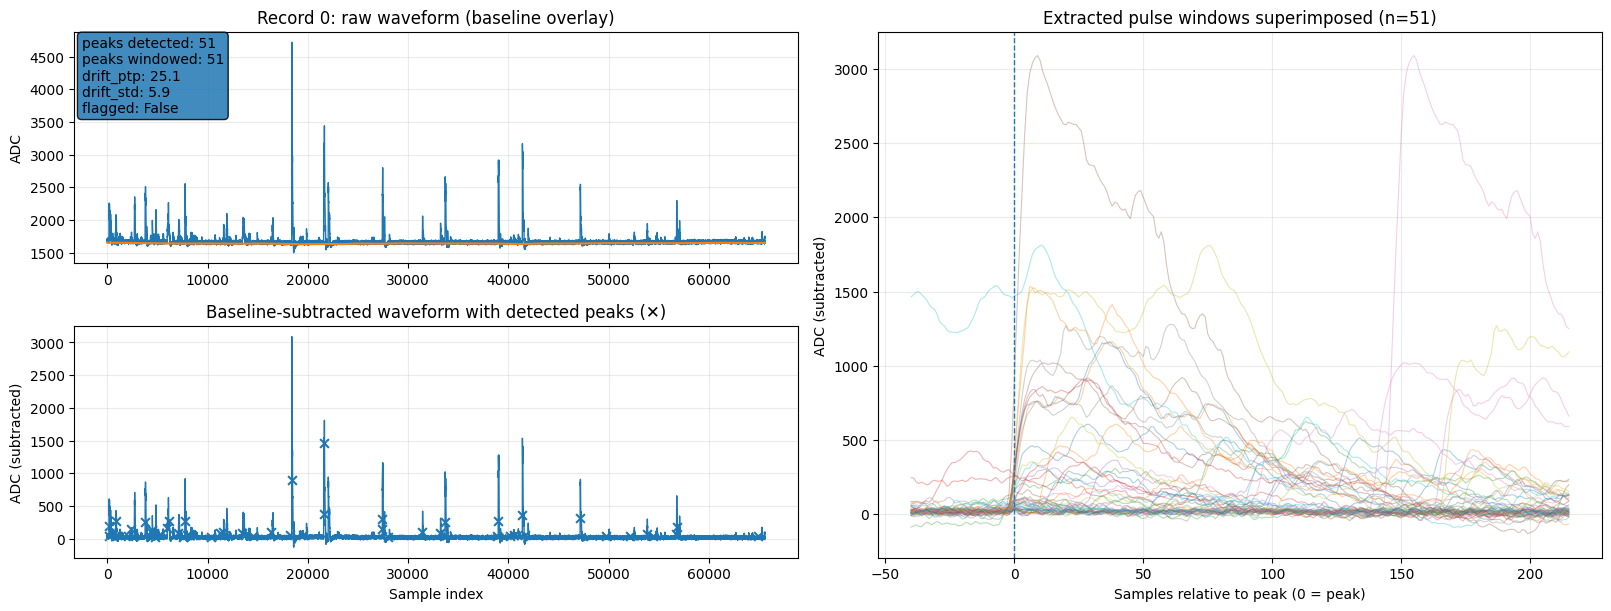

In [5]:
windows, peak_positions = plot_record_qc_from_result(
    X,
    results[0],
    pre=40,
    post=216
)

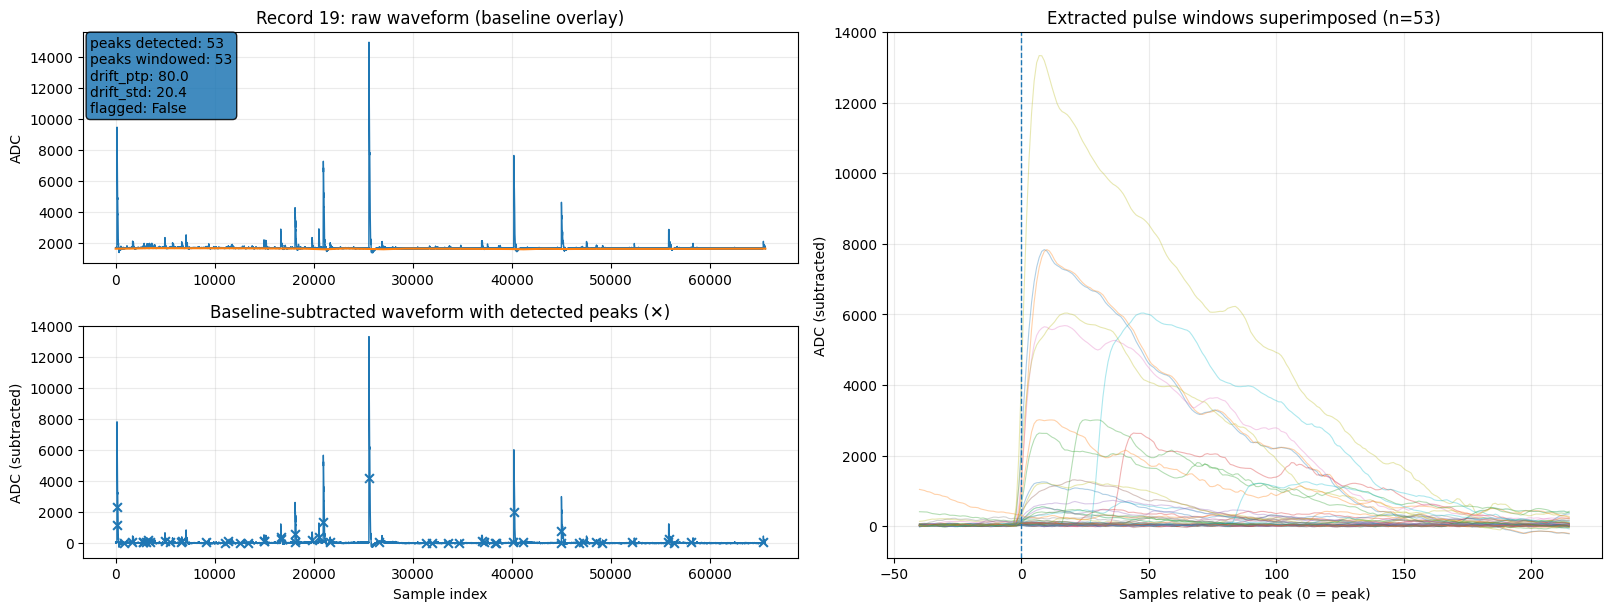

In [6]:
windows, peak_positions = plot_record_qc_from_result(
    X,
    results[19],
    pre=40,
    post=216
)

In [7]:
results[id]["peaks_idx"]

array([  139,   529,  1139,  1711,  2878,  3170,  3416,  3654,  3900,
        4981,  5745,  6672,  7115,  9406, 11369, 11779, 12972, 13782,
       14978, 15155, 16671, 17128, 18116, 18465, 19841, 20520, 20971,
       21665, 25578, 26914, 31699, 32297, 33705, 34849, 37011, 37546,
       38669, 38836, 40213, 40446, 41577, 45011, 45384, 47132, 47545,
       48540, 49163, 52369, 55853, 56072, 56712, 58300, 65402],
      dtype=int32)

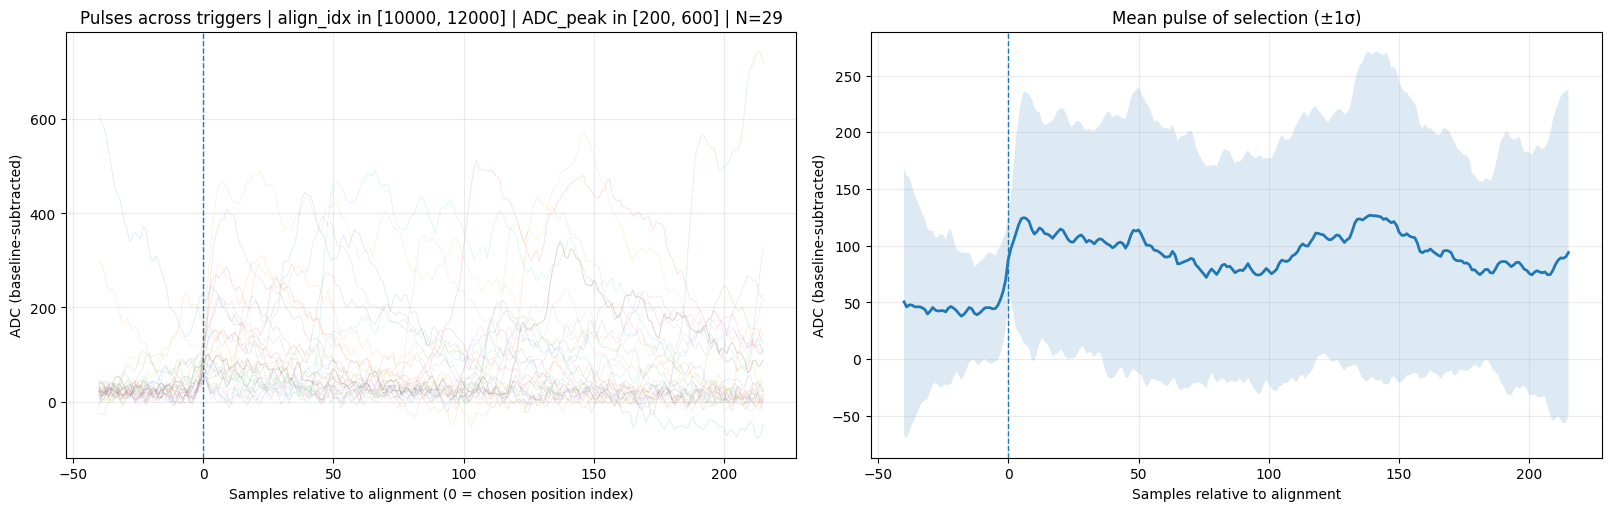

In [8]:
wins, meta = plot_pulses_across_triggers(
    X, results,
    pos_side="between", pos_cut=(10000, 12000),
    amp_side="between", amp_cut=(200, 600),
    mean_mode="separate"
)

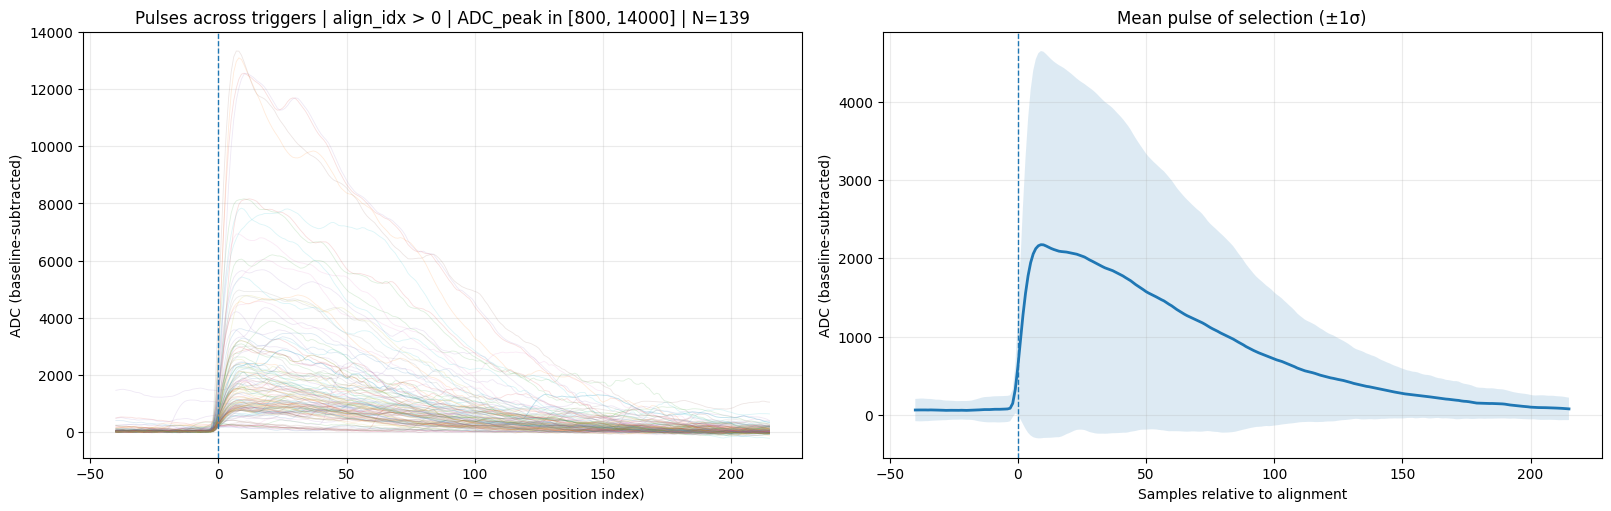

In [9]:
wins, meta = plot_pulses_across_triggers(
    X, results,
    pos_side="after", pos_cut=0,
    amp_side="between", amp_cut=[800, 14000],
    mean_mode="separate"
)

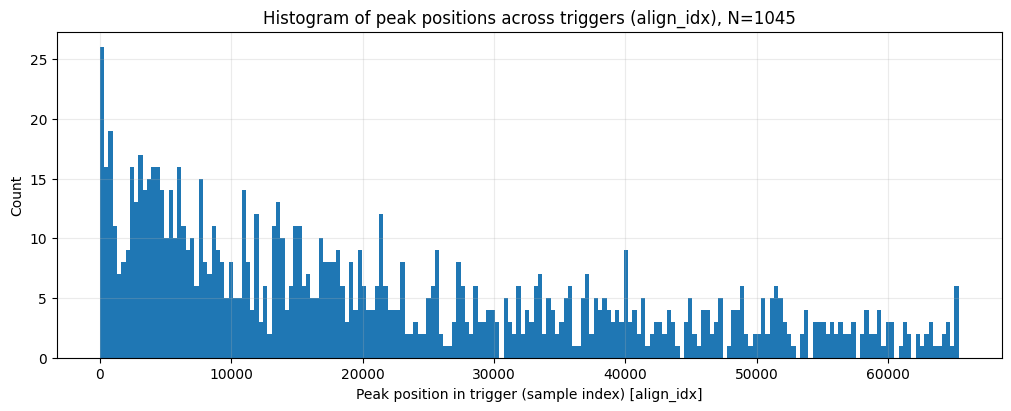

In [10]:
pos = plot_peak_position_histogram(results, use="align", bins=200)

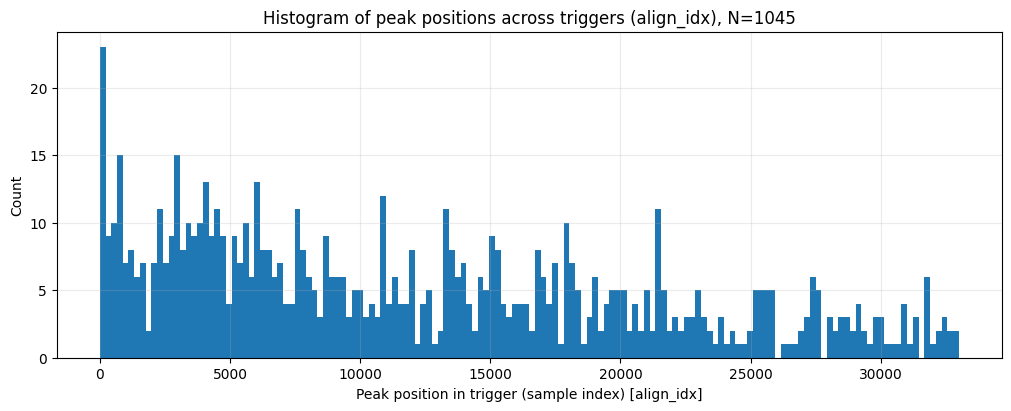

In [11]:
pos = plot_peak_position_histogram(results, use="align", bins=150, range=(0, 33000))

In [12]:

def plot_peak_position_histogram(
    results,
    *,
    use: str = "align",                 # "align" or "argmax"
    bins: int | np.ndarray = 200,
    range: tuple[int, int] | None = None,
    skip_flagged: bool = False,
    density: bool = False,
    title: str | None = None,

    # new: overlay per-record histograms
    overlay_per_record: bool = False,
    overlay_mode: str = "density",      # "density" or "count"
    overlay_alpha: float = 0.20,
    overlay_linewidth: float = 1.0,
):
    """
    Plot histogram of peak positions across all trigger records, with optional
    per-record histogram overlays.

    Returns:
      positions_all: 1D np.ndarray of all collected peak positions
    """
    use = str(use).strip().lower()
    if use not in ("align", "argmax"):
        raise ValueError("use must be 'align' or 'argmax'")

    overlay_mode = str(overlay_mode).strip().lower()
    if overlay_mode not in ("density", "count"):
        raise ValueError("overlay_mode must be 'density' or 'count'")

    key = "align_idx" if use == "align" else "peaks_idx"

    # Collect per-record arrays (and global)
    per_record = []
    for res in results:
        if skip_flagged and bool(res.get("flagged_drift", False)):
            continue
        arr = np.asarray(res.get(key, []), dtype=np.int64)
        arr = arr[arr >= 0]  # ignore -1 alignment failures if present
        if arr.size > 0:
            per_record.append(arr)

    if len(per_record) == 0:
        print("No peak positions found (check 'use' or skip_flagged settings).")
        return np.array([], dtype=np.int64)

    positions_all = np.concatenate(per_record)

    # Determine histogram bin edges for consistency
    if isinstance(bins, int):
        # use numpy to create consistent edges
        lo = positions_all.min() if range is None else range[0]
        hi = positions_all.max() if range is None else range[1]
        edges = np.linspace(lo, hi, bins + 1)
    else:
        edges = np.asarray(bins)

    fig, ax = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)

    # Optional per-record overlays
    if overlay_per_record:
        for arr in per_record:
            ax.hist(
                arr,
                bins=edges,
                histtype="step",
                density=(overlay_mode == "density"),
                linewidth=overlay_linewidth,
                alpha=overlay_alpha,
            )

    # Global histogram (main)
    ax.hist(
        positions_all,
        bins=edges,
        density=density,
        alpha=0.9
    )

    ax.set_xlabel(f"Peak position in trigger (sample index) [{key}]")
    ax.set_ylabel("Density" if density else "Count")
    ax.grid(True, alpha=0.25)

    if title is None:
        title = f"Peak-position histogram across triggers ({key}), N={len(positions_all)}"
        if skip_flagged:
            title += " (excluding drift-flagged records)"
        if overlay_per_record:
            title += f" + per-record overlays ({overlay_mode})"
    ax.set_title(title)

    plt.show()
    return positions_all

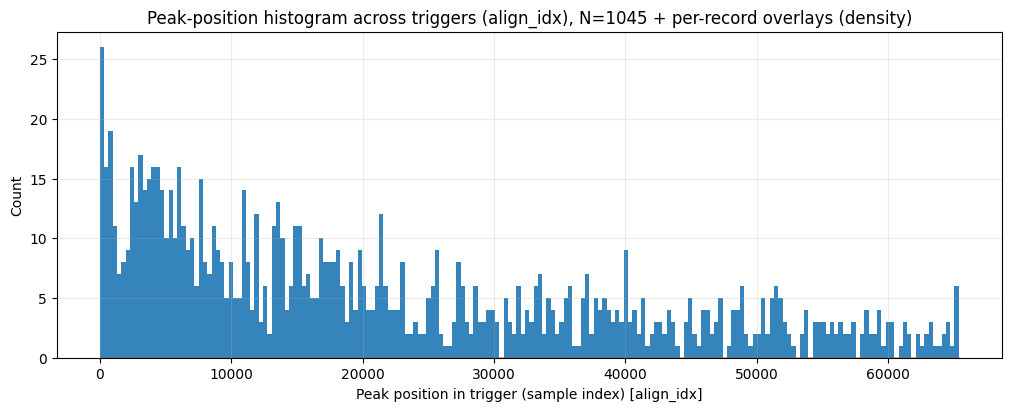

In [13]:
pos = plot_peak_position_histogram(
    results,
    use="align",
    bins=200,
    overlay_per_record=True,
    overlay_mode="density",
    density=False  # global stays as counts; set True if you want global density too
)